# Amazon Reviews — Sentiment Analysis

**Pipeline:** Data Loading -> EDA -> Text Preprocessing -> Feature Extraction -> Model Training -> Evaluation & Comparison

In [8]:
# ============================================================
# COLAB SETUP — Chạy cell này đầu tiên khi dùng Google Colab
# ============================================================
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/Duyduide/sentiment-analysis-ml.git"
    REPO_DIR = "/content/sentiment-analysis-ml"

    # 1. Clone hoặc pull repo
    if not os.path.exists(REPO_DIR):
        os.system(f"git clone {REPO_URL} {REPO_DIR}")
    else:
        os.system(f"git -C {REPO_DIR} pull")

    # 2. Chuyển working dir vào notebooks/ để các path tương đối (../data/, ../features/) hoạt động đúng
    os.chdir(f"{REPO_DIR}/notebooks")
    sys.path.insert(0, REPO_DIR)

    # 3. Cài thêm thư viện chưa có sẵn trong Colab
    os.system("pip install -q 'kagglehub[pandas-datasets]' wordcloud")

    print("Colab setup xong. Working dir:", os.getcwd())
    print("Python path includes:", REPO_DIR)
else:
    print("Chạy local — bỏ qua Colab setup.")


Colab setup xong. Working dir: /content/sentiment-analysis-ml/notebooks
Python path includes: /content/sentiment-analysis-ml


---
## 1. Set up môi trường

In [9]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words("english"))

%matplotlib inline
print("Environment ready.")

Environment ready.


---
## 2. Load dữ liệu

### Kaggle API Setup (bắt buộc)

**Bước 1 — Tạo token**
1. Vào: https://www.kaggle.com/settings/account
2. Tìm mục **API Tokens (Recommended)** -> nhấn **Generate New Token**
3. Copy token vừa hiện ra

**Bước 2 — Khi notebook yêu cầu**
- Nhập **Kaggle username** và dán **API token** vừa copy

In [10]:
import kagglehub
import os
import shutil

path = kagglehub.dataset_download("dongrelaxman/amazon-reviews-dataset")
print("Dataset path:", path)

for file in os.listdir(path):
    if file.endswith(".csv"):
        dest = "../data/amazon_reviews.csv"
        os.makedirs("../data", exist_ok=True)
        shutil.copy(os.path.join(path, file), dest)
        print(f"Copied -> {dest}")
        break

100%|██████████| 4.59M/4.59M [00:01<00:00, 3.14MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/dongrelaxman/amazon-reviews-dataset/versions/1
Copied -> ../data/amazon_reviews.csv


In [11]:
df = pd.read_csv(
    "../data/amazon_reviews.csv",
    engine="python",
    encoding="utf-8",
    on_bad_lines="skip",
)
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (21214, 9)


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [12]:
from modules.preprocessing import extract_rating, convert_sentiment

df["rating_num"] = df["Rating"].apply(extract_rating)
df["sentiment"]  = df["rating_num"].apply(convert_sentiment)

df = df.dropna(subset=["rating_num", "sentiment"]).reset_index(drop=True)
print(f"Shape after label extraction: {df.shape}")
df[["Rating", "rating_num", "sentiment"]].head()

Shape after label extraction: (21055, 11)


,Rating,rating_num,sentiment
0,Rated 1 out of 5 stars,1.0,negative
1,Rated 1 out of 5 stars,1.0,negative
2,Rated 1 out of 5 stars,1.0,negative
3,Rated 1 out of 5 stars,1.0,negative
4,Rated 1 out of 5 stars,1.0,negative


---
## 3. Exploratory Data Analysis

In [13]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (21055, 11)

Column dtypes:
Reviewer Name          object
Profile Link           object
Country                object
Review Count           object
Review Date            object
Rating                 object
Review Title           object
Review Text            object
Date of Experience     object
rating_num            float64
sentiment              object
dtype: object

Missing values:
Reviewer Name           0
Profile Link            0
Country                 1
Review Count            0
Review Date             0
Rating                  0
Review Title            0
Review Text             0
Date of Experience    108
rating_num              0
sentiment               0
dtype: int64


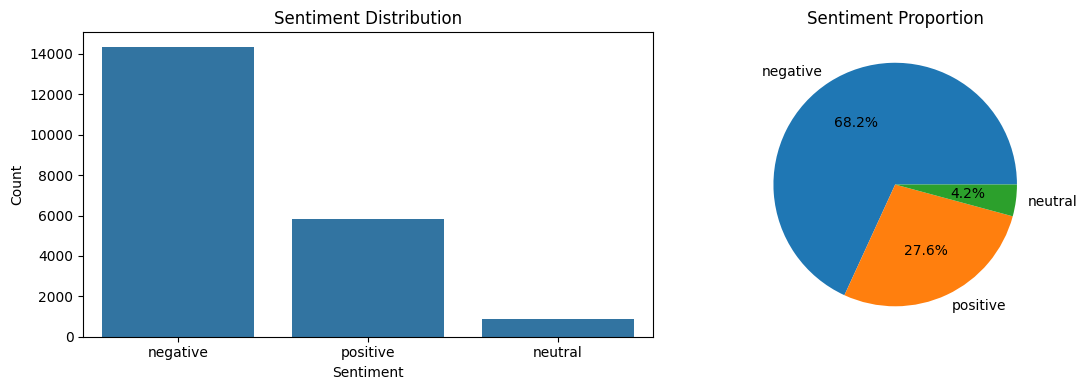

Sentiment counts:
sentiment
negative    14350
positive     5820
neutral       885
Name: count, dtype: int64


In [14]:
counts = df["sentiment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="sentiment", data=df, order=counts.index, ax=axes[0])
axes[0].set_title("Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

counts.plot(kind="pie", autopct="%1.1f%%", ax=axes[1])
axes[1].set_title("Sentiment Proportion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("Sentiment counts:")
print(counts)

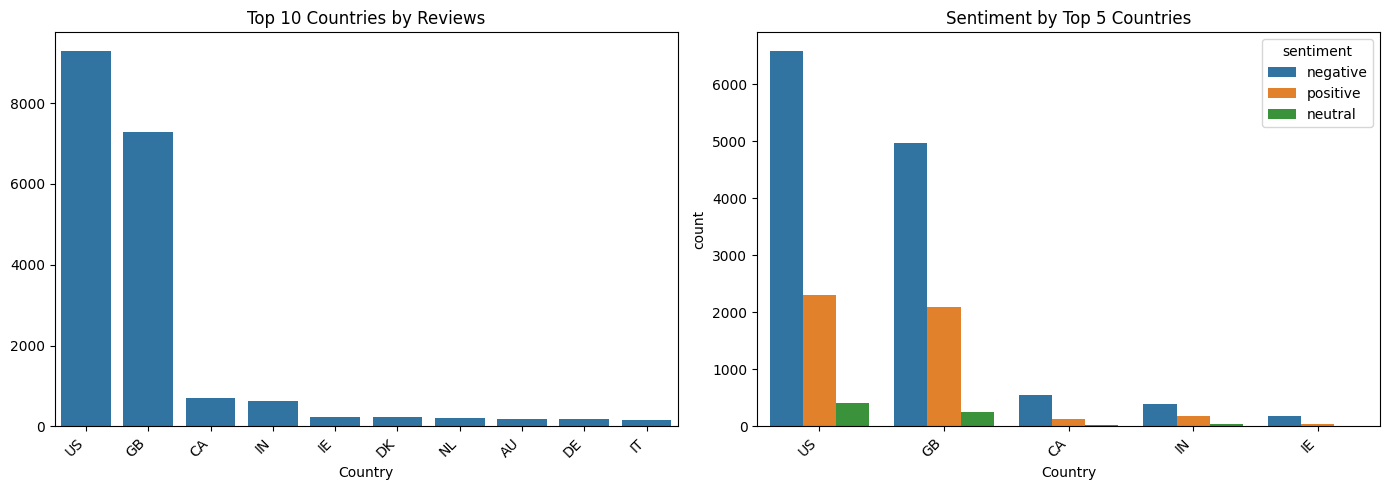

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10 = df["Country"].value_counts().head(10)
sns.barplot(x=top10.index, y=top10.values, ax=axes[0])
axes[0].set_title("Top 10 Countries by Reviews")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

top5 = df["Country"].value_counts().head(5).index
df_top5 = df[df["Country"].isin(top5)]
sns.countplot(x="Country", hue="sentiment", data=df_top5, ax=axes[1])
axes[1].set_title("Sentiment by Top 5 Countries")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

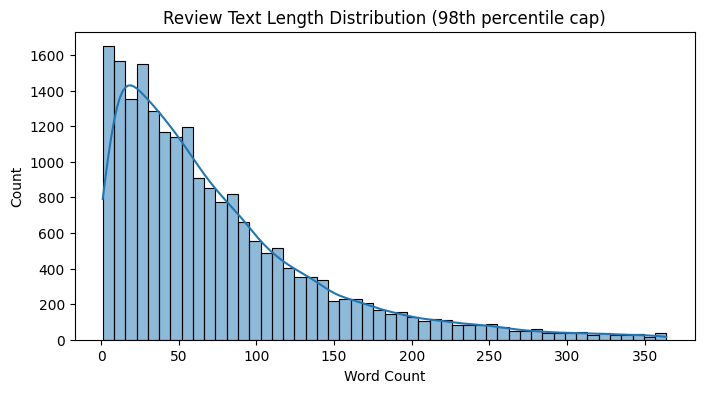

Mean length : 83.8 words
Median length: 57 words


In [16]:
df["text_length"] = df["Review Text"].astype(str).apply(lambda x: len(x.split()))
upper = np.percentile(df["text_length"], 98)

plt.figure(figsize=(8, 4))
sns.histplot(df[df["text_length"] <= upper]["text_length"], bins=50, kde=True)
plt.title("Review Text Length Distribution (98th percentile cap)")
plt.xlabel("Word Count")
plt.show()

print(f"Mean length : {df['text_length'].mean():.1f} words")
print(f"Median length: {df['text_length'].median():.0f} words")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


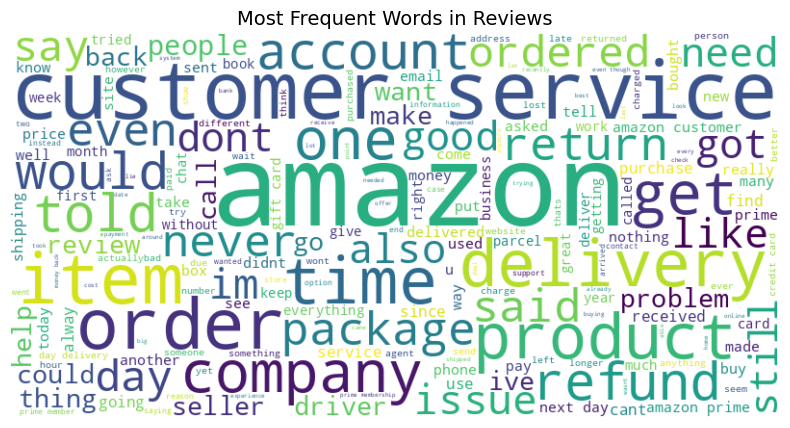

In [17]:
from modules.preprocessing import preprocess_pipeline
import nltk

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab')

sample_text = " ".join(
    df["Review Text"].sample(5000, random_state=42).astype(str).apply(preprocess_pipeline)
)

wordcloud = WordCloud(
    width=800, height=400,
    stopwords=STOP_WORDS,
    background_color="white",
    max_words=200,
).generate(sample_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Reviews", fontsize=14)
plt.show()

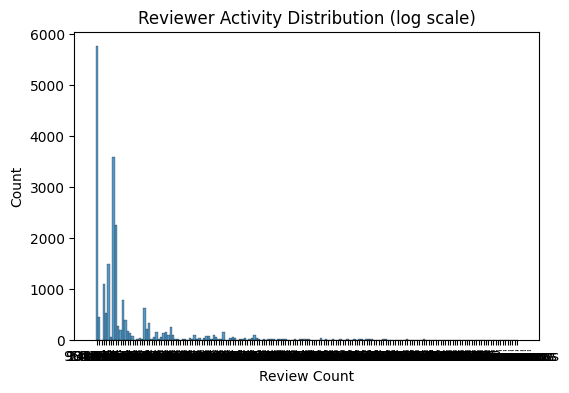

In [18]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Review Count"], bins=30, log_scale=True)
plt.title("Reviewer Activity Distribution (log scale)")
plt.xlabel("Review Count")
plt.show()

---
## 4. Text Preprocessing

Áp dụng pipeline: lowercase -> remove URLs/HTML -> remove special chars -> remove stopwords.

In [19]:
from modules.preprocessing import preprocess_dataframe, download_nltk_resources

download_nltk_resources()

df = preprocess_dataframe(
    df,
    text_col="Review Text",
    output_col="clean_text",
    use_lemmatization=False,
)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print(f"Rows after filtering empty texts: {len(df)}")
df[["Review Text", "clean_text"]].head()

Rows after filtering empty texts: 21055


,Review Text,clean_text
0,"I registered on the website, tried to order a ...",registered website tried order laptop entered ...
1,Had multiple orders one turned up and driver h...,multiple orders one turned driver phone door n...
2,I informed these reprobates that I WOULD NOT B...,informed reprobates would going visit sick rel...
3,I have bought from Amazon before and no proble...,bought amazon problems happy service price ama...
4,If I could give a lower rate I would! I cancel...,could give lower rate would cancelled amazon p...


---
## 5. Feature Extraction

### 5.1 TF-IDF Features

In [20]:
from modules.features import FeatureExtractor
from modules.utils import save_features

X_text = df["clean_text"].tolist()
y      = df["sentiment"]

extractor = FeatureExtractor(max_tfidf_features=5000)
X_tfidf   = extractor.extract_tfidf(X_text, fit=True)

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Sample features:", extractor.tfidf_vectorizer.get_feature_names_out()[:20])

save_features(X_tfidf.toarray(), "../features/tfidf_features.npy")

TF-IDF matrix shape: (21055, 5000)
Sample features: ['ability' 'able' 'able get' 'able help' 'absolute' 'absolute joke'
 'absolutely' 'absolutely disgusting' 'absolutely love'
 'absolutely nothing' 'absolutely ridiculous' 'absolutely shocking'
 'absolutely terrible' 'absolutely useless' 'absurd' 'abuse' 'abusive'
 'abysmal' 'accent' 'accept']
[utils] Features saved → ../features/tfidf_features.npy  (shape: (21055, 5000))


### 5.2 Bag-of-Words Features

In [21]:
X_bow = extractor.extract_bow(X_text, fit=True)

print("BoW matrix shape:", X_bow.shape)
print("Sample features:", extractor.bow_vectorizer.get_feature_names_out()[:20])

save_features(X_bow.toarray(), "../features/bow_features.npy")

BoW matrix shape: (21055, 5000)
Sample features: ['ability' 'able' 'able get' 'able help' 'absolute' 'absolute joke'
 'absolutely' 'absolutely disgusting' 'absolutely love'
 'absolutely nothing' 'absolutely ridiculous' 'absolutely shocking'
 'absolutely terrible' 'absolutely useless' 'absurd' 'abuse' 'abusive'
 'abysmal' 'accent' 'accept']
[utils] Features saved → ../features/bow_features.npy  (shape: (21055, 5000))


### 5.3 DistilBERT Embeddings

DistilBERT được dùng để trích xuất embeddings từ `[CLS]` token trên **toàn bộ tập dữ liệu** để so sánh công bằng với TF-IDF và BoW.

In [22]:
X_bert = extractor.extract_bert(df["clean_text"].tolist(), batch_size=32)

print("BERT embeddings shape:", X_bert.shape)

save_features(X_bert, "../features/bert_embeddings.npy")

[FeatureExtractor] Loading DistilBERT model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[FeatureExtractor] Model loaded on cuda


Extracting BERT embeddings: 100%|██████████| 658/658 [01:05<00:00, 10.01it/s]


BERT embeddings shape: (21055, 768)
[utils] Features saved → ../features/bert_embeddings.npy  (shape: (21055, 768))


In [23]:
# download feature extraction file (.npy)
# from google.colab import files
# files.download('../features/bow_features.npy')
# files.download('../features/tfidf_features.npy')
# files.download('../features/bert_embeddings.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 6. Model Training

### 6.1 TF-IDF + Classical Classifiers

Các mô hình: Logistic Regression, Naive Bayes, Decision Tree.

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from modules.models import get_classifiers, train_model
import numpy as np

le        = LabelEncoder()
y_encoded = le.fit_transform(y)
LABELS    = list(le.classes_)
print("Classes:", LABELS)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Compute per-sample weights to correct class imbalance
cw = compute_class_weight("balanced", classes=np.arange(len(LABELS)), y=y_train)
sw = np.array([cw[label] for label in y_train])
print("Class weights:", dict(zip(LABELS, cw.round(3))))

classifiers = get_classifiers()
# LR and DT use class_weight="balanced" internally (set in get_classifiers)
lr_model    = train_model(classifiers["Logistic Regression"], X_train, y_train)
# NB does not support class_weight -> pass sample_weight explicitly
nb_model    = train_model(classifiers["Naive Bayes"],         X_train, y_train, sample_weight=sw)
dt_model    = train_model(classifiers["Decision Tree"],       X_train, y_train)

print("TF-IDF models trained.")


Classes: ['negative', 'neutral', 'positive']
Train: (16844, 5000), Test: (4211, 5000)
Class weights: {'negative': np.float64(0.489), 'neutral': np.float64(7.93), 'positive': np.float64(1.206)}
TF-IDF models trained.


### 6.2 BoW + Classical Classifiers

In [25]:
X_bow_train, X_bow_test, y_bow_train, y_bow_test = train_test_split(
    X_bow, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)
print(f"Train: {X_bow_train.shape}, Test: {X_bow_test.shape}")

# Compute per-sample weights to correct class imbalance for BoW models
cw_bow = compute_class_weight("balanced", classes=np.arange(len(LABELS)), y=y_bow_train)
sw_bow = np.array([cw_bow[label] for label in y_bow_train])
print("Class weights:", dict(zip(LABELS, cw_bow.round(3))))

bow_classifiers = get_classifiers()
# LR and DT use class_weight="balanced" internally (set in get_classifiers)
bow_lr_model = train_model(bow_classifiers["Logistic Regression"], X_bow_train, y_bow_train)
# NB does not support class_weight -> pass sample_weight explicitly
bow_nb_model = train_model(bow_classifiers["Naive Bayes"],         X_bow_train, y_bow_train, sample_weight=sw_bow)
bow_dt_model = train_model(bow_classifiers["Decision Tree"],       X_bow_train, y_bow_train)

print("BoW models trained.")

Train: (16844, 5000), Test: (4211, 5000)
Class weights: {'negative': np.float64(0.489), 'neutral': np.float64(7.93), 'positive': np.float64(1.206)}
BoW models trained.


### 6.3 DistilBERT Embeddings + Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bert, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)
print(f"Train: {Xb_train.shape}, Test: {Xb_test.shape}")

# class_weight="balanced" accounts for class imbalance
bert_lr_model = train_model(LogisticRegression(max_iter=1000, class_weight="balanced"), Xb_train, yb_train)
print("BERT + Logistic Regression trained.")

Train: (16844, 768), Test: (4211, 768)
BERT + Logistic Regression trained.


---
## 7. Evaluation & Comparison

### 7.1 TF-IDF Model Evaluations

===== Logistic Regression (TF-IDF) =====
Accuracy:        0.8478
Macro F1:        0.6571
Weighted F1:     0.8621
ROC-AUC (macro): 0.8897

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.87      0.91      2870
     neutral       0.16      0.32      0.22       177
    positive       0.83      0.86      0.85      1164

    accuracy                           0.85      4211
   macro avg       0.65      0.69      0.66      4211
weighted avg       0.88      0.85      0.86      4211



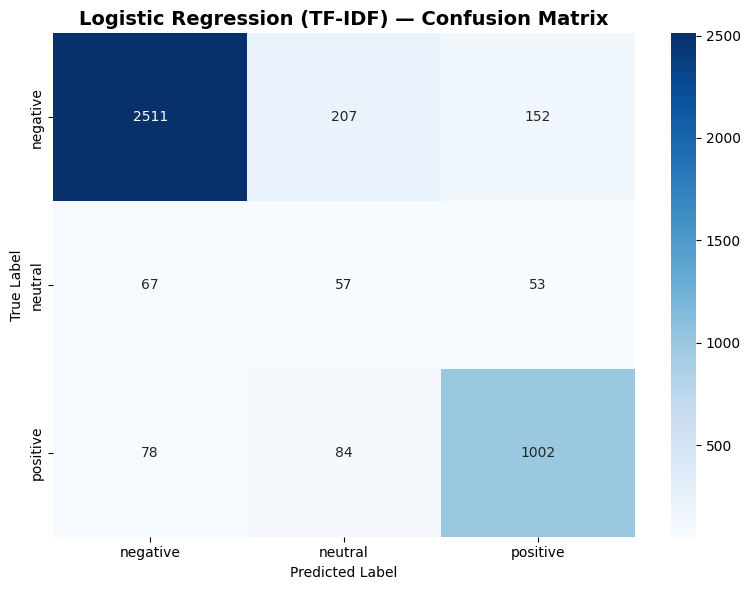

===== Naive Bayes (TF-IDF) =====
Accuracy:        0.8285
Macro F1:        0.6477
Weighted F1:     0.8529
ROC-AUC (macro): 0.8877

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.84      0.89      2870
     neutral       0.14      0.36      0.20       177
    positive       0.84      0.86      0.85      1164

    accuracy                           0.83      4211
   macro avg       0.64      0.69      0.65      4211
weighted avg       0.89      0.83      0.85      4211



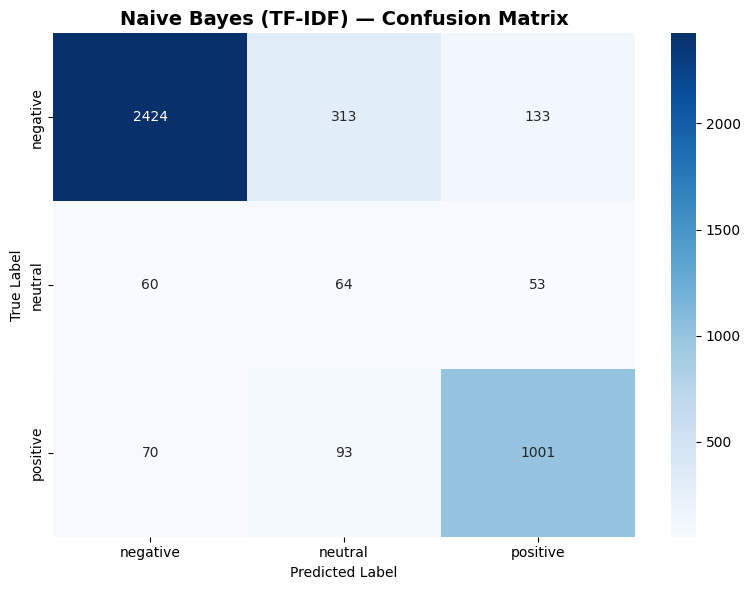

===== Decision Tree (TF-IDF) =====
Accuracy:        0.7160
Macro F1:        0.5338
Weighted F1:     0.7491
ROC-AUC (macro): 0.7354

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.78      0.82      2870
     neutral       0.07      0.24      0.11       177
    positive       0.72      0.63      0.67      1164

    accuracy                           0.72      4211
   macro avg       0.55      0.55      0.53      4211
weighted avg       0.79      0.72      0.75      4211



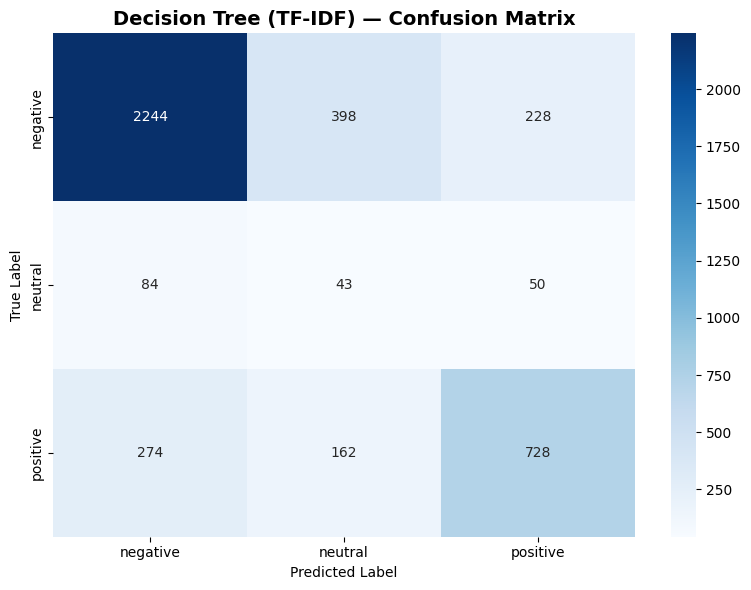

In [27]:
from modules.models import evaluate_model

y_pred_lr = lr_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

acc_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression (TF-IDF)", labels=LABELS, y_proba=lr_model.predict_proba(X_test))
acc_nb = evaluate_model(y_test, y_pred_nb, "Naive Bayes (TF-IDF)",         labels=LABELS, y_proba=nb_model.predict_proba(X_test))
acc_dt = evaluate_model(y_test, y_pred_dt, "Decision Tree (TF-IDF)",       labels=LABELS, y_proba=dt_model.predict_proba(X_test))


### 7.2 BoW Model Evaluations

===== Logistic Regression (BoW) =====
Accuracy:        0.8475
Macro F1:        0.6402
Weighted F1:     0.8568
ROC-AUC (macro): 0.8673

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.87      0.91      2870
     neutral       0.15      0.23      0.18       177
    positive       0.79      0.88      0.83      1164

    accuracy                           0.85      4211
   macro avg       0.63      0.66      0.64      4211
weighted avg       0.87      0.85      0.86      4211



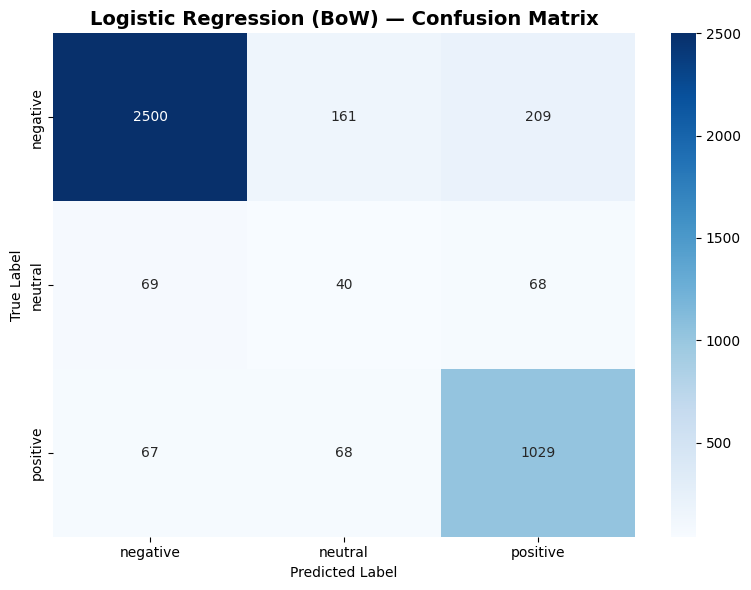

===== Naive Bayes (BoW) =====
Accuracy:        0.8231
Macro F1:        0.6381
Weighted F1:     0.8453
ROC-AUC (macro): 0.8682

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.83      0.89      2870
     neutral       0.13      0.32      0.18       177
    positive       0.80      0.89      0.85      1164

    accuracy                           0.82      4211
   macro avg       0.63      0.68      0.64      4211
weighted avg       0.88      0.82      0.85      4211



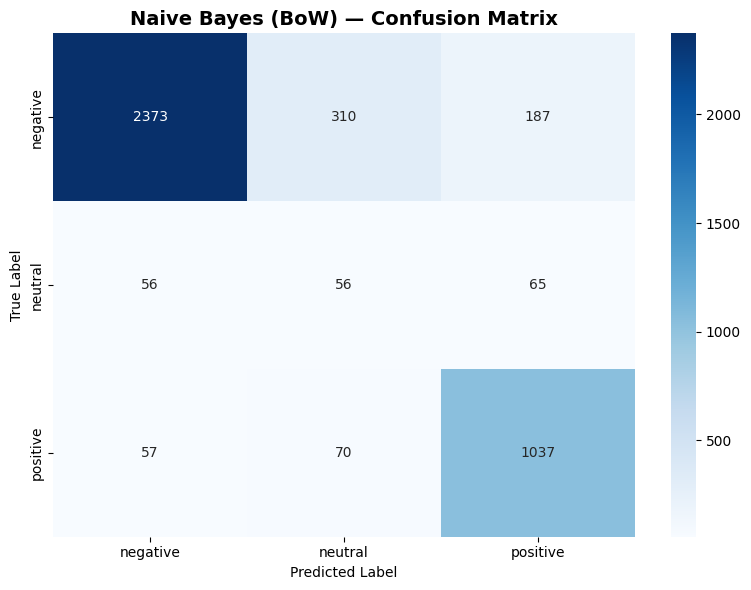

===== Decision Tree (BoW) =====
Accuracy:        0.6561
Macro F1:        0.5042
Weighted F1:     0.7113
ROC-AUC (macro): 0.7144

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.70      0.78      2870
     neutral       0.06      0.30      0.10       177
    positive       0.67      0.59      0.63      1164

    accuracy                           0.66      4211
   macro avg       0.54      0.53      0.50      4211
weighted avg       0.79      0.66      0.71      4211



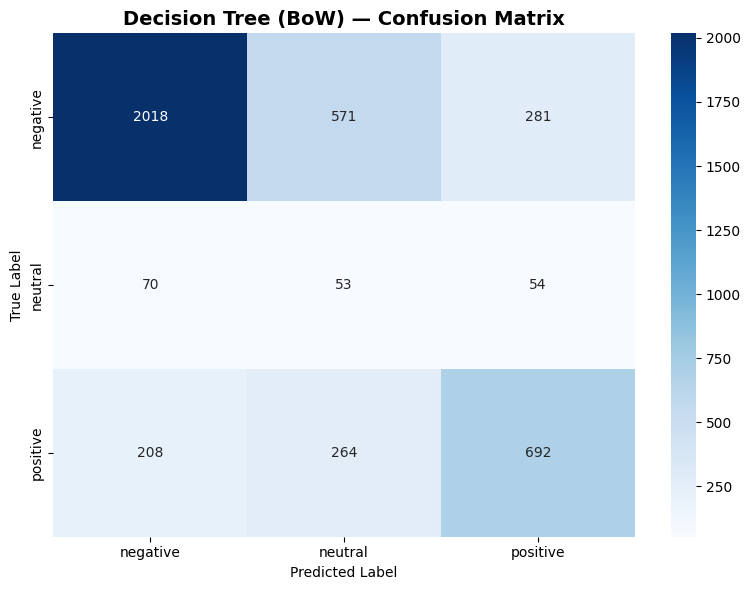

In [28]:
y_pred_bow_lr = bow_lr_model.predict(X_bow_test)
y_pred_bow_nb = bow_nb_model.predict(X_bow_test)
y_pred_bow_dt = bow_dt_model.predict(X_bow_test)

acc_bow_lr = evaluate_model(y_bow_test, y_pred_bow_lr, "Logistic Regression (BoW)", labels=LABELS, y_proba=bow_lr_model.predict_proba(X_bow_test))
acc_bow_nb = evaluate_model(y_bow_test, y_pred_bow_nb, "Naive Bayes (BoW)",         labels=LABELS, y_proba=bow_nb_model.predict_proba(X_bow_test))
acc_bow_dt = evaluate_model(y_bow_test, y_pred_bow_dt, "Decision Tree (BoW)",       labels=LABELS, y_proba=bow_dt_model.predict_proba(X_bow_test))


### 7.3 DistilBERT + LR Evaluation

===== BERT + Logistic Regression =====
Accuracy:        0.7839
Macro F1:        0.6108
Weighted F1:     0.8195
ROC-AUC (macro): 0.8725

Classification Report:
              precision    recall  f1-score   support

    negative       0.95      0.79      0.86      2870
     neutral       0.10      0.34      0.16       177
    positive       0.79      0.83      0.81      1164

    accuracy                           0.78      4211
   macro avg       0.61      0.66      0.61      4211
weighted avg       0.87      0.78      0.82      4211



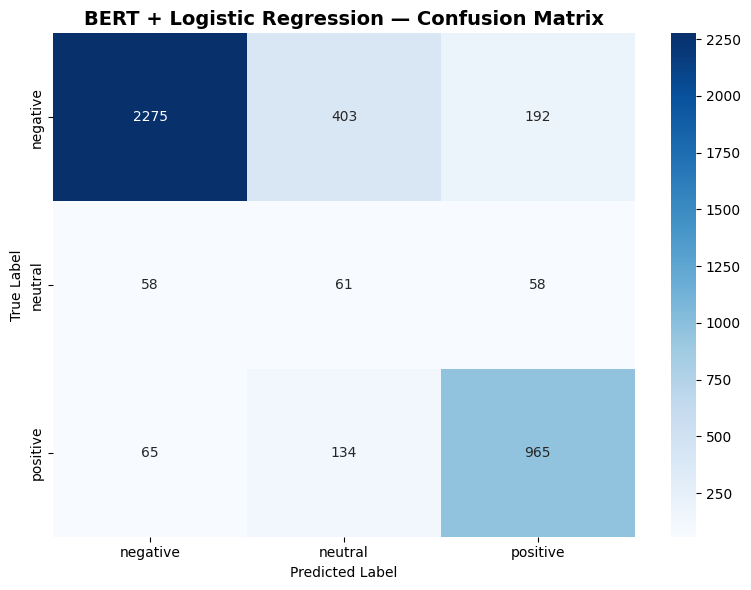

In [29]:
yb_pred  = bert_lr_model.predict(Xb_test)
acc_bert = evaluate_model(yb_test, yb_pred, "BERT + Logistic Regression", labels=LABELS, y_proba=bert_lr_model.predict_proba(Xb_test))


### 7.4 Overall Model Comparison

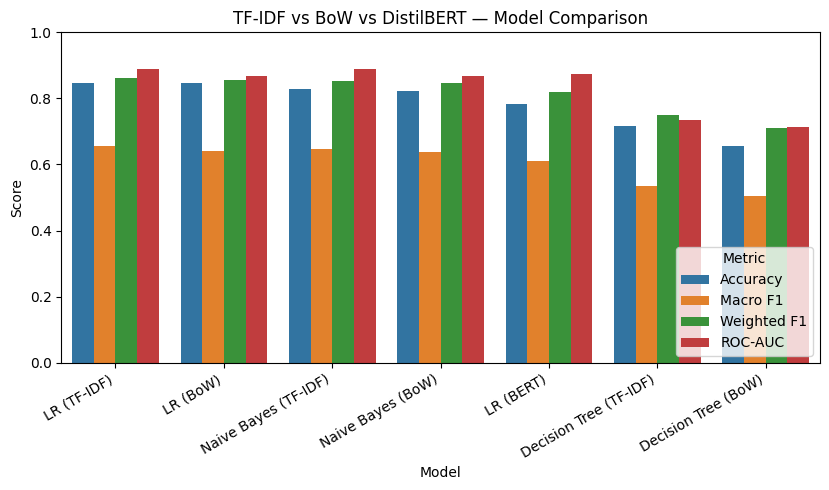

,Model,Accuracy,Macro F1,Weighted F1,ROC-AUC
0,LR (TF-IDF),0.847780,0.657050,0.862148,0.889738
1,LR (BoW),0.847542,0.640224,0.856766,0.867255
2,Naive Bayes (TF-IDF),0.828544,0.647731,0.852872,0.887717
3,Naive Bayes (BoW),0.823082,0.638104,0.845317,0.868174
4,LR (BERT),0.783899,0.610797,0.819523,0.872535
5,Decision Tree (TF-IDF),0.715982,0.533800,0.749092,0.735395
6,Decision Tree (BoW),0.656139,0.504156,0.711258,0.714359


In [30]:
from modules.models import compare_models

all_results = {
    "LR (TF-IDF)"          : acc_lr,
    "Naive Bayes (TF-IDF)": acc_nb,
    "Decision Tree (TF-IDF)": acc_dt,
    "LR (BoW)"             : acc_bow_lr,
    "Naive Bayes (BoW)"    : acc_bow_nb,
    "Decision Tree (BoW)"  : acc_bow_dt,
    "LR (BERT)"            : acc_bert,
}

comparison_df = compare_models(all_results, title="TF-IDF vs BoW vs DistilBERT — Model Comparison")
comparison_df